In [1]:
import os
import random
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import seaborn as sns

In [2]:
SEED = 42
BATCH_SIZE = 64
IMG_SIZE = 224
EPOCHS = 5
LR = 1e-4
NUM_WORKERS = 2

DATASET_ROOT = Path("/kaggle/input")
WORKING_ROOT = Path("/kaggle/working")
PREPARED_ROOT = WORKING_ROOT / "prepared_140k_faces"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)
print("Device:", device)

Device: cuda


In [3]:
for p in DATASET_ROOT.iterdir():
    print(p)

/kaggle/input/datasets


In [6]:



dataset_path = "/kaggle/input/datasets/xhlulu/140k-real-and-fake-faces"
print("Chosen dataset path:", dataset_path)

Chosen dataset path: /kaggle/input/datasets/xhlulu/140k-real-and-fake-faces


In [7]:
def show_tree(path, level=2, indent=""):
    path = Path(path)
    if level < 0 or not path.exists():
        return
    items = sorted(list(path.iterdir()))[:20]
    for item in items:
        print(indent + ("📁 " if item.is_dir() else "📄 ") + item.name)
        if item.is_dir():
            show_tree(item, level - 1, indent + "    ")

show_tree(dataset_path, level=2)

📁 real_vs_fake
    📁 real-vs-fake
        📁 test
        📁 train
        📁 valid
📄 test.csv
📄 train.csv
📄 valid.csv


In [8]:
def copy_subset(src_files, dst_dir):
    dst_dir.mkdir(parents=True, exist_ok=True)
    for f in src_files:
        shutil.copy2(f, dst_dir / f.name)

def prepare_dataset(dataset_path, out_root, seed=42):
    dataset_path = Path(dataset_path)
    out_root = Path(out_root)

    split_names = {"train", "training", "val", "valid", "validation", "test"}
    top_dirs = [d for d in dataset_path.iterdir() if d.is_dir()]
    top_names = {d.name.lower() for d in top_dirs}

    if len(top_names.intersection(split_names)) >= 2:
        print("Detected pre-split dataset.")
        mapping = {}
        for d in top_dirs:
            n = d.name.lower()
            if n in {"train", "training"}:
                mapping["train"] = d
            elif n in {"val", "valid", "validation"}:
                mapping["val"] = d
            elif n == "test":
                mapping["test"] = d
        return mapping

    print("Detected unsplit dataset. Creating train/val/test split...")
    real_dir, fake_dir = None, None

    for d in dataset_path.rglob("*"):
        if d.is_dir():
            n = d.name.lower()
            if n == "real":
                real_dir = d
            elif n == "fake":
                fake_dir = d

    if real_dir is None or fake_dir is None:
        raise ValueError("Could not find real/ and fake/ folders.")

    real_files = sorted([f for f in real_dir.glob("*") if f.suffix.lower() in {".jpg", ".jpeg", ".png"}])
    fake_files = sorted([f for f in fake_dir.glob("*") if f.suffix.lower() in {".jpg", ".jpeg", ".png"}])

    rng = random.Random(seed)
    rng.shuffle(real_files)
    rng.shuffle(fake_files)

    def split_list(files):
        n = len(files)
        n_train = int(0.70 * n)
        n_val = int(0.15 * n)
        train_files = files[:n_train]
        val_files = files[n_train:n_train+n_val]
        test_files = files[n_train+n_val:]
        return train_files, val_files, test_files

    real_train, real_val, real_test = split_list(real_files)
    fake_train, fake_val, fake_test = split_list(fake_files)

    if out_root.exists():
        shutil.rmtree(out_root)

    copy_subset(real_train, out_root / "train" / "real")
    copy_subset(fake_train, out_root / "train" / "fake")
    copy_subset(real_val, out_root / "val" / "real")
    copy_subset(fake_val, out_root / "val" / "fake")
    copy_subset(real_test, out_root / "test" / "real")
    copy_subset(fake_test, out_root / "test" / "fake")

    return {
        "train": out_root / "train",
        "val": out_root / "val",
        "test": out_root / "test"
    }

splits = prepare_dataset(dataset_path, PREPARED_ROOT, seed=SEED)
print(splits)

Detected unsplit dataset. Creating train/val/test split...
{'train': PosixPath('/kaggle/working/prepared_140k_faces/train'), 'val': PosixPath('/kaggle/working/prepared_140k_faces/val'), 'test': PosixPath('/kaggle/working/prepared_140k_faces/test')}


In [9]:
train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_test_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_ds = datasets.ImageFolder(splits["train"], transform=train_tfms)
val_ds = datasets.ImageFolder(splits["val"], transform=val_test_tfms)
test_ds = datasets.ImageFolder(splits["test"], transform=val_test_tfms)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

class_names = train_ds.classes
print("Classes:", class_names)
print("Train size:", len(train_ds))
print("Val size:", len(val_ds))
print("Test size:", len(test_ds))

Classes: ['fake', 'real']
Train size: 70000
Val size: 15000
Test size: 15000


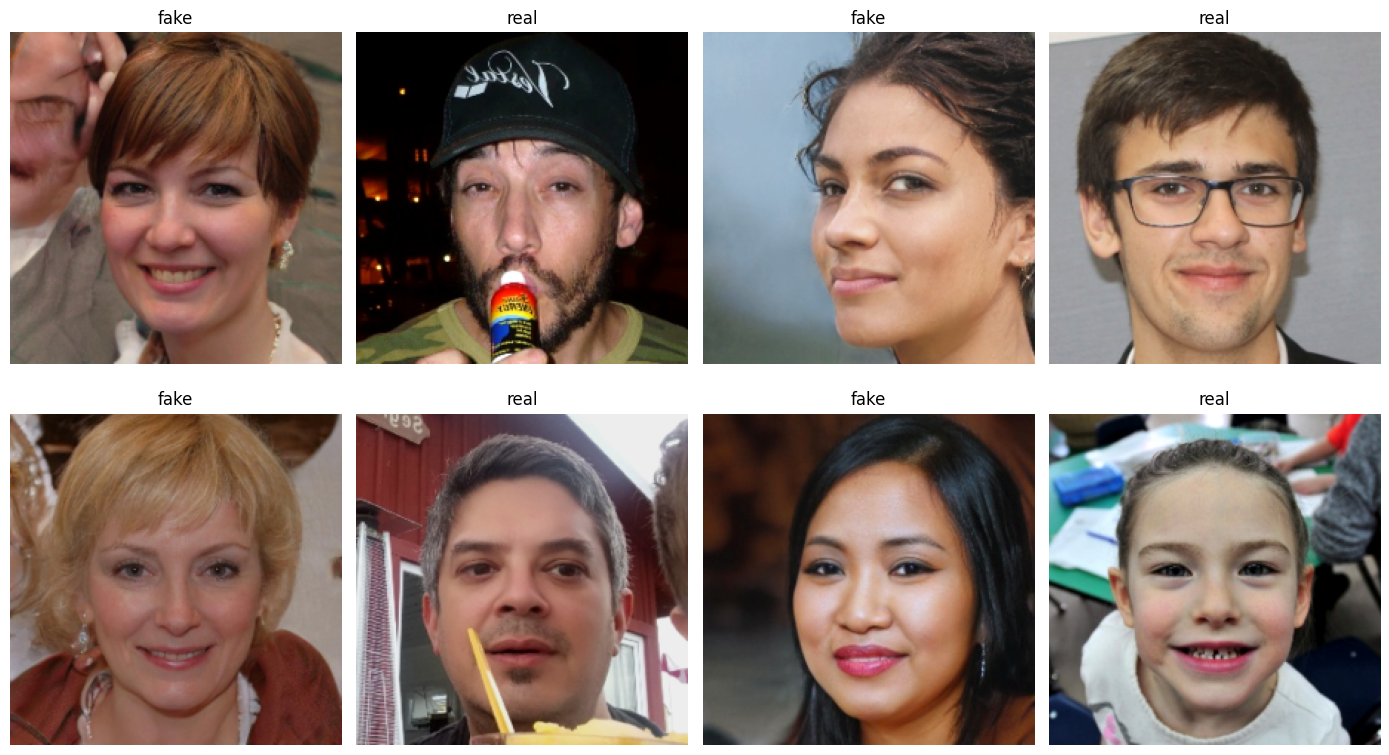

In [10]:
def imshow_tensor(img_tensor, title=None):
    img = img_tensor.cpu().numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    if title:
        plt.title(title)
    plt.axis("off")

images, labels = next(iter(train_loader))
plt.figure(figsize=(14, 8))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    imshow_tensor(images[i], title=class_names[labels[i].item()])
plt.tight_layout()
plt.show()

In [11]:
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

in_features = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(in_features, 1)
)

model = model.to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", patience=1, factor=0.5)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 138MB/s] 


In [13]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = (torch.sigmoid(outputs) >= 0.5).float()
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_probs = []
    all_labels = []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        probs = torch.sigmoid(outputs)
        preds = (probs >= 0.5).float()

        running_loss += loss.item() * images.size(0)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        all_probs.extend(probs.squeeze(1).cpu().numpy())
        all_labels.extend(labels.squeeze(1).cpu().numpy())

    auc = roc_auc_score(all_labels, all_probs)
    return running_loss / total, correct / total, auc, np.array(all_probs), np.array(all_labels)

In [14]:
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "val_auc": []
}

best_val_acc = 0.0
best_model_path = WORKING_ROOT / "best_model_140k_faces.pth"

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, val_auc, _, _ = evaluate(model, val_loader, criterion, device)

    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_auc"].append(val_auc)

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f} | Val AUC: {val_auc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)
        print("Saved best model.")

Epoch 1/5
Train Loss: 0.1125 | Train Acc: 0.9545
Val   Loss: 0.0224 | Val   Acc: 0.9923 | Val AUC: 0.9998
Saved best model.
Epoch 2/5
Train Loss: 0.0240 | Train Acc: 0.9918
Val   Loss: 0.0087 | Val   Acc: 0.9970 | Val AUC: 1.0000
Saved best model.
Epoch 3/5
Train Loss: 0.0138 | Train Acc: 0.9953
Val   Loss: 0.0113 | Val   Acc: 0.9963 | Val AUC: 1.0000
Epoch 4/5
Train Loss: 0.0106 | Train Acc: 0.9964
Val   Loss: 0.0104 | Val   Acc: 0.9965 | Val AUC: 1.0000
Epoch 5/5
Train Loss: 0.0052 | Train Acc: 0.9982
Val   Loss: 0.0047 | Val   Acc: 0.9983 | Val AUC: 1.0000
Saved best model.


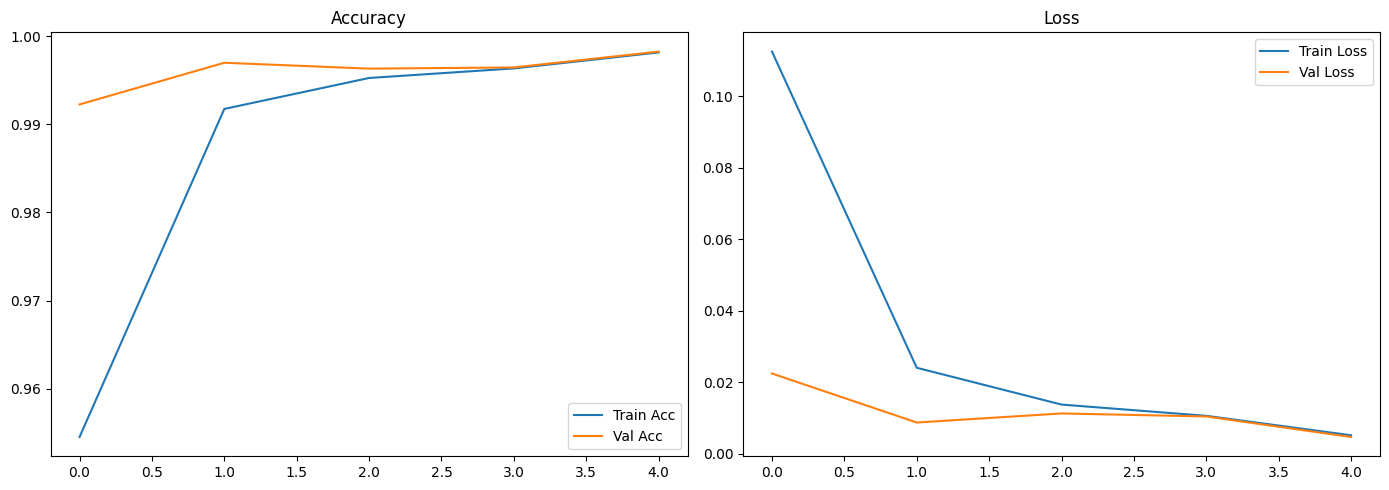

In [15]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history["train_acc"], label="Train Acc")
plt.plot(history["val_acc"], label="Val Acc")
plt.title("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.title("Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [16]:
best_model = models.efficientnet_b0(weights=None)
in_features = best_model.classifier[1].in_features
best_model.classifier = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(in_features, 1)
)
best_model.load_state_dict(torch.load(best_model_path, map_location=device))
best_model = best_model.to(device)

test_loss, test_acc, test_auc, test_probs, test_labels = evaluate(best_model, test_loader, criterion, device)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Acc : {test_acc:.4f}")
print(f"Test AUC : {test_auc:.4f}")

Test Loss: 0.0042
Test Acc : 0.9985
Test AUC : 1.0000


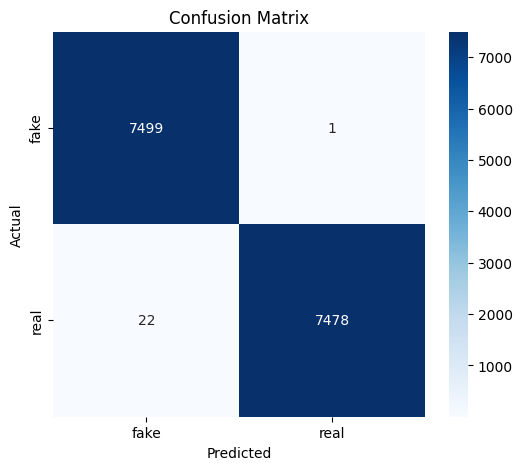

              precision    recall  f1-score   support

        fake       1.00      1.00      1.00      7500
        real       1.00      1.00      1.00      7500

    accuracy                           1.00     15000
   macro avg       1.00      1.00      1.00     15000
weighted avg       1.00      1.00      1.00     15000



In [17]:
test_preds = (test_probs >= 0.5).astype(int)
cm = confusion_matrix(test_labels.astype(int), test_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(test_labels.astype(int), test_preds, target_names=class_names))

In [18]:
torch.save({
    "model_state_dict": best_model.state_dict(),
    "class_names": class_names,
    "img_size": IMG_SIZE,
    "model_name": "efficientnet_b0"
}, WORKING_ROOT / "face_authenticity_detector_full.pth")

print("Saved:", WORKING_ROOT / "face_authenticity_detector_full.pth")

Saved: /kaggle/working/face_authenticity_detector_full.pth


In [20]:
infer_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

def predict_image(image_path, model, class_names, device):
    image = Image.open(image_path).convert("RGB")
    x = infer_tfms(image).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        logits = model(x)
        prob_fake = torch.sigmoid(logits).item()

    pred_idx = 1 if prob_fake >= 0.5 else 0
    label = class_names[pred_idx]
    confidence = prob_fake if pred_idx == 1 else (1 - prob_fake)

    plt.figure(figsize=(4, 4))
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"Prediction: {label} | Confidence: {confidence:.4f}")
    plt.show()

    return {"label": label, "confidence": confidence, "prob_fake": prob_fake}

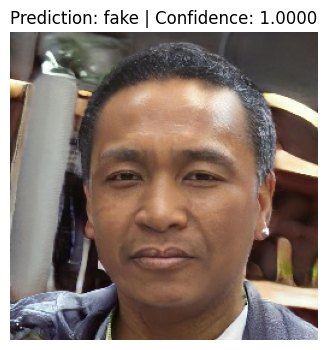

{'label': 'fake', 'confidence': 0.9999999999987342, 'prob_fake': 1.265760933566451e-12}


In [21]:
sample_path = next(iter((Path(splits["test"]) / "fake").glob("*")))
result = predict_image(sample_path, best_model, class_names, device)
print(result)